Dataset Shape: (10000, 32)

Data Types:
customer id                object
gender                     object
age                         int64
country                    object
city                       object
customer segment           object
tenure months               int64
signup channel             object
contract type              object
monthly logins              int64
weekly active days          int64
avg session time          float64
features used               int64
usage growth rate         float64
last login days ago         int64
monthly fee                 int64
total revenue               int64
payment method             object
payment failures            int64
discount applied           object
price increase last 3m     object
support tickets             int64
avg resolution time       float64
complaint type             object
csat score                  int64
escalations                 int64
email open rate           float64
marketing click rate      float64
nps scor

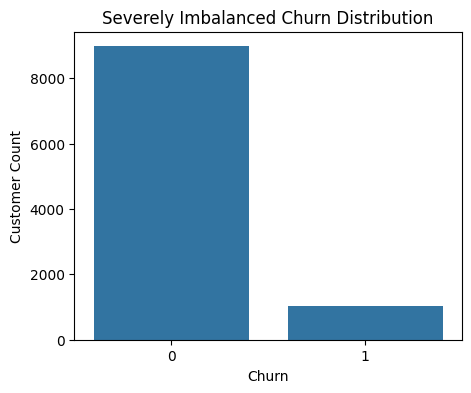

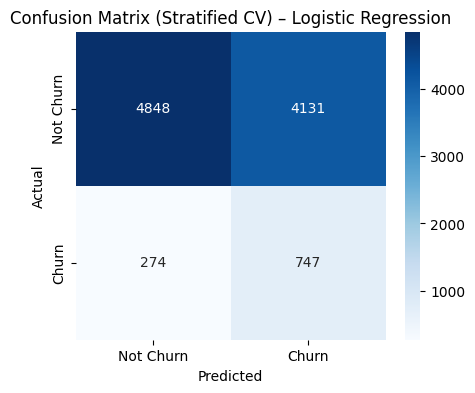

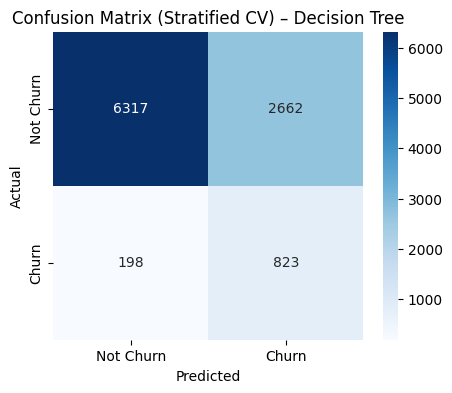

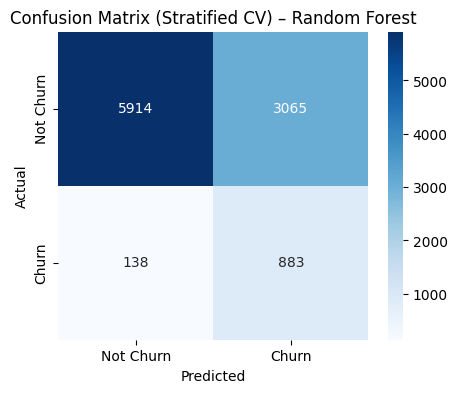

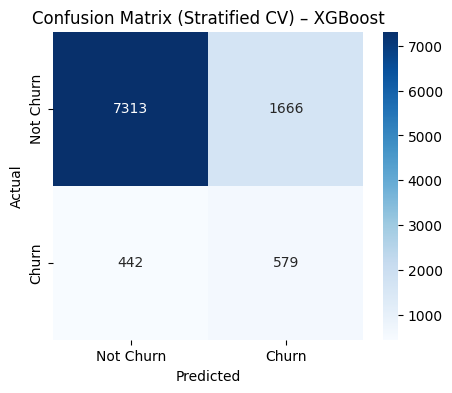


Model Comparison (Recall & F1 using Stratified CV):
                 Model    Recall  F1 Score
2        Random Forest  0.864838  0.355404
1        Decision Tree  0.806072  0.365291
0  Logistic Regression  0.731636  0.253263
3              XGBoost  0.567091  0.354562


In [2]:
# =========================
# 1. IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, recall_score, f1_score


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('/content/customer_churn_buisness_dataset.csv')

df.columns = df.columns.str.lower().str.replace('_', ' ', regex=False)


# =========================
# 3. BASIC EDA
# =========================
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution (Counts):")
print(df['churn'].value_counts())

print("\nTarget Distribution (%):")
print(df['churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df)
plt.title('Severely Imbalanced Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')
plt.show()


# =========================
# 4. DATA CLEANING
# =========================
df['discount applied'] = df['discount applied'].map({'Yes': 1, 'No': 0})
df['price increase last 3m'] = df['price increase last 3m'].map({'Yes': 1, 'No': 0})

df = df.drop(columns=['customer id'])

y = df['churn']
X = df.drop(columns=['churn'])

cat_cols = [
    'gender','country','city','customer segment','signup channel',
    'contract type','payment method','complaint type',
    'nps score','survey response'
]


# =========================
# 5. STRATIFIED K-FOLD
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

threshold = 0.40
scale_pos = y.value_counts()[0] / y.value_counts()[1]


# =========================
# 6. MODELS
# =========================
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight='balanced', random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced', random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        gamma=0.1,
        min_child_weight=1,
        reg_alpha=0.1,
        reg_lambda=0.1,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
}


# =========================
# 7. STRATIFIED CV (NO LEAKAGE)
# =========================
results = []

for name, model in models.items():

    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ---- ONE-HOT ENCODING AFTER SPLIT ----
        X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
        X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

        X_train, X_test = X_train.align(
            X_test, join='left', axis=1, fill_value=0
        )
        # ------------------------------------

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        preds = (probs >= threshold).astype(int)

        all_y_true.extend(y_test)
        all_y_pred.extend(preds)

    recall = recall_score(all_y_true, all_y_pred)
    f1 = f1_score(all_y_true, all_y_pred)

    results.append((name, recall, f1))

    cm = confusion_matrix(all_y_true, all_y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Not Churn', 'Churn'],
        yticklabels=['Not Churn', 'Churn']
    )
    plt.title(f'Confusion Matrix (Stratified CV) – {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# =========================
# 8. FINAL COMPARISON
# =========================
results_df = pd.DataFrame(
    results, columns=['Model', 'Recall', 'F1 Score']
).sort_values(by='Recall', ascending=False)

print("\nModel Comparison (Recall & F1 using Stratified CV):")
print(results_df)
